# PGS002771 cross-ancestry portability analyses

Code used to reproduce the final variant-level analyses and figures reported in the manuscript.

Analyses include:
1. Cross-ancestry numerical displacement and driver recurrence
2. Weight- and allele-frequency-matched recurrence analysis
3. Comparison with ancestry-specific T2D effect estimates
4. Prediction of large cross-ancestry effect differences
5. Exploratory local LD analysis

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 20260830
rng = np.random.default_rng(SEED)

In [1]:
BASE = "https://raw.githubusercontent.com/laiacm1/pipe/main"

## 1. Numerical displacement and cross-ancestry recurrence

Variant-level numerical displacement was calculated from the fixed PGS002771 weights and ancestry-specific effect-allele frequencies. Variants were ranked separately for each non-European ancestry comparison.

In [3]:
freq = pd.read_csv(
    f"{BASE}/multi_ancestry_freq_all_chr.csv"
)

ancestries = ["SAS", "EAS", "AFR", "AMR"]

for ancestry in ancestries:
    freq[f"delta_{ancestry}"] = (
        2 * freq["effect_weight"] *
        (freq[f"{ancestry}_effect_AF"] - freq["EUR_effect_AF"])
    )
    freq[f"abs_delta_{ancestry}"] = freq[f"delta_{ancestry}"].abs()

top_sets = {}

for ancestry in ancestries:
    col = f"abs_delta_{ancestry}"
    cutoff = freq[col].quantile(0.90)
    top_sets[ancestry] = set(
        freq.loc[freq[col] >= cutoff, "rsID"]
    )

freq["top10_count"] = sum(
    freq["rsID"].isin(top_sets[a]).astype(int)
    for a in ancestries
)

recurrence = (
    freq["top10_count"]
    .value_counts()
    .reindex(range(5), fill_value=0)
    .sort_index()
)

print(recurrence)

top10_count
0    4517
1     471
2     269
3     217
4     148
Name: count, dtype: int64


In [5]:
# Pairwise overlap of top-displacement variants

pairwise_rows = []

for i, a1 in enumerate(ancestries):
    for a2 in ancestries[i + 1:]:
        overlap = len(top_sets[a1] & top_sets[a2])
        union = len(top_sets[a1] | top_sets[a2])
        jaccard = overlap / union

        pairwise_rows.append({
            "comparison": f"{a1}-{a2}",
            "overlap": overlap,
            "jaccard": jaccard
        })

pairwise_overlap = pd.DataFrame(pairwise_rows)

print(pairwise_overlap)

  comparison  overlap   jaccard
0    SAS-EAS      347  0.445443
1    SAS-AFR      273  0.320047
2    SAS-AMR      302  0.366505
3    EAS-AFR      279  0.329398
4    EAS-AMR      339  0.430750
5    AFR-AMR      268  0.312354


## 2. Weight- and allele-frequency-matched recurrence null

To test whether four-way recurrence exceeded expectation from PGS weight magnitude and overall ancestry allele-frequency divergence, variants were divided into 25 matched strata defined by weight quintile and allele-frequency-divergence quintile. Top-driver labels were permuted within strata across 10,000 iterations.

In [19]:
# Weight- and allele-frequency-matched recurrence null

af_cols = [f"{a}_effect_AF" for a in ancestries]

freq["af_divergence"] = (
    freq[af_cols]
    .sub(freq["EUR_effect_AF"], axis=0)
    .abs()
    .mean(axis=1)
)

freq["abs_weight"] = freq["effect_weight"].abs()

freq["weight_bin"] = pd.qcut(
    freq["abs_weight"],
    5,
    labels=False,
    duplicates="drop"
)

freq["af_bin"] = (
    freq.groupby("weight_bin", group_keys=False)["af_divergence"]
    .apply(lambda x: pd.qcut(x, 5, labels=False, duplicates="drop"))
)

freq["stratum"] = (
    freq["weight_bin"].astype(str)
    + "_"
    + freq["af_bin"].astype(str)
)

top_flags = pd.DataFrame({
    ancestry: freq["rsID"].isin(top_sets[ancestry]).astype(int)
    for ancestry in ancestries
})

observed = int((top_flags.sum(axis=1) == 4).sum())

n_perm = 10_000
null_counts = np.empty(n_perm, dtype=int)

strata = freq.groupby("stratum").indices

for i in range(n_perm):
    permuted = np.zeros((len(freq), len(ancestries)), dtype=int)

    for idx in strata.values():
        idx = np.asarray(idx)

        for j, ancestry in enumerate(ancestries):
            permuted[idx, j] = rng.permutation(
                top_flags.loc[idx, ancestry].to_numpy()
            )

    null_counts[i] = np.sum(permuted.sum(axis=1) == 4)

null_mean = null_counts.mean()
ci_low, ci_high = np.percentile(null_counts, [2.5, 97.5])
p_empirical = (np.sum(null_counts >= observed) + 1) / (n_perm + 1)

print("Observed:", observed)
print("Null mean:", null_mean)
print("95% interval:", ci_low, ci_high)
print("Empirical P:", p_empirical)

Observed: 148
Null mean: 110.482
95% interval: 99.0 122.0
Empirical P: 9.999000099990002e-05


## 3. Cross-ancestry T2D effect differences

Numerical PGS displacement was compared with ancestry-specific T2D effect estimates from T2DGGI. Effect estimates were aligned to the PGS effect allele before calculating standardized cross-ancestry effect differences for EUR-SAS and EUR-EAS.

In [4]:
# Load aligned T2DGGI effect-portability results

effect = pd.read_csv(
    f"{BASE}/PGS002771_T2DGGI_effect_portability_master.csv"
)

comparisons = {
    "SAS": {
        "displacement": "abs_delta_SAS_minus_EUR",
        "effect_difference": "abs_z_diff_SAS_EUR"
    },
    "EAS": {
        "displacement": "abs_delta_EAS_minus_EUR",
        "effect_difference": "abs_z_diff_EAS_EUR"
    }
}

correlation_rows = []

for ancestry, cols in comparisons.items():
    d = effect[
        [cols["displacement"], cols["effect_difference"]]
    ].dropna()

    rho, p = spearmanr(
        d[cols["displacement"]],
        d[cols["effect_difference"]]
    )

    correlation_rows.append({
        "comparison": f"EUR-{ancestry}",
        "n": len(d),
        "rho": rho,
        "p_value": p
    })

effect_correlations = pd.DataFrame(correlation_rows)

print(effect_correlations)

  comparison     n       rho       p_value
0    EUR-SAS  5620  0.021541  1.063760e-01
1    EUR-EAS  5618  0.067163  4.688191e-07


## 4. Prediction of large cross-ancestry T2D effect differences

Variants in the top 10% of absolute standardized cross-ancestry T2D effect difference were treated as the positive class. Numerical displacement, absolute PGS weight, and allele-frequency difference were evaluated individually, followed by a combined weight and allele-frequency model using stratified five-fold cross-validation.

In [17]:
# Predict top-10% cross-ancestry effect differences

prediction_rows = []
cv_rows = []

for ancestry, cols in comparisons.items():
    d = effect[
        [
            cols["displacement"],
            cols["effect_difference"],
            "effect_weight",
            f"{ancestry}_effect_AF",
            "EUR_effect_AF"
        ]
    ].dropna().copy()

    d["abs_weight"] = d["effect_weight"].abs()
    d["af_difference"] = (
        d[f"{ancestry}_effect_AF"] - d["EUR_effect_AF"]
    ).abs()

    threshold = d[cols["effect_difference"]].quantile(0.90)
    y = (d[cols["effect_difference"]] >= threshold).astype(int)

    predictors = {
        "numerical_displacement": d[cols["displacement"]],
        "PGS_weight": d["abs_weight"],
        "AF_difference": d["af_difference"]
    }

    for name, values in predictors.items():
        prediction_rows.append({
            "comparison": f"EUR-{ancestry}",
            "predictor": name,
            "roc_auc": roc_auc_score(y, values),
            "average_precision": average_precision_score(y, values)
        })

    X = d[["abs_weight", "af_difference"]]

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000)
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    )

    probabilities = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method="predict_proba"
    )[:, 1]

    cv_rows.append({
        "comparison": f"EUR-{ancestry}",
        "roc_auc": roc_auc_score(y, probabilities),
        "average_precision": average_precision_score(y, probabilities)
    })

prediction_results = pd.DataFrame(prediction_rows)
cv_results = pd.DataFrame(cv_rows)

print(prediction_results)
print()
print(cv_results)

  comparison               predictor   roc_auc  average_precision
0    EUR-SAS  numerical_displacement  0.519290           0.112711
1    EUR-SAS              PGS_weight  0.516611           0.113187
2    EUR-SAS           AF_difference  0.504310           0.104183
3    EUR-EAS  numerical_displacement  0.597158           0.167631
4    EUR-EAS              PGS_weight  0.583785           0.165127
5    EUR-EAS           AF_difference  0.551628           0.115993

  comparison   roc_auc  average_precision
0    EUR-SAS  0.512798           0.112246
1    EUR-EAS  0.596871           0.164821


## 5. Final figures

Figures 2 and 3 summarize numerical displacement, cross-ancestry recurrence, and the relationship between numerical PGS displacement and standardized cross-ancestry T2D effect differences.

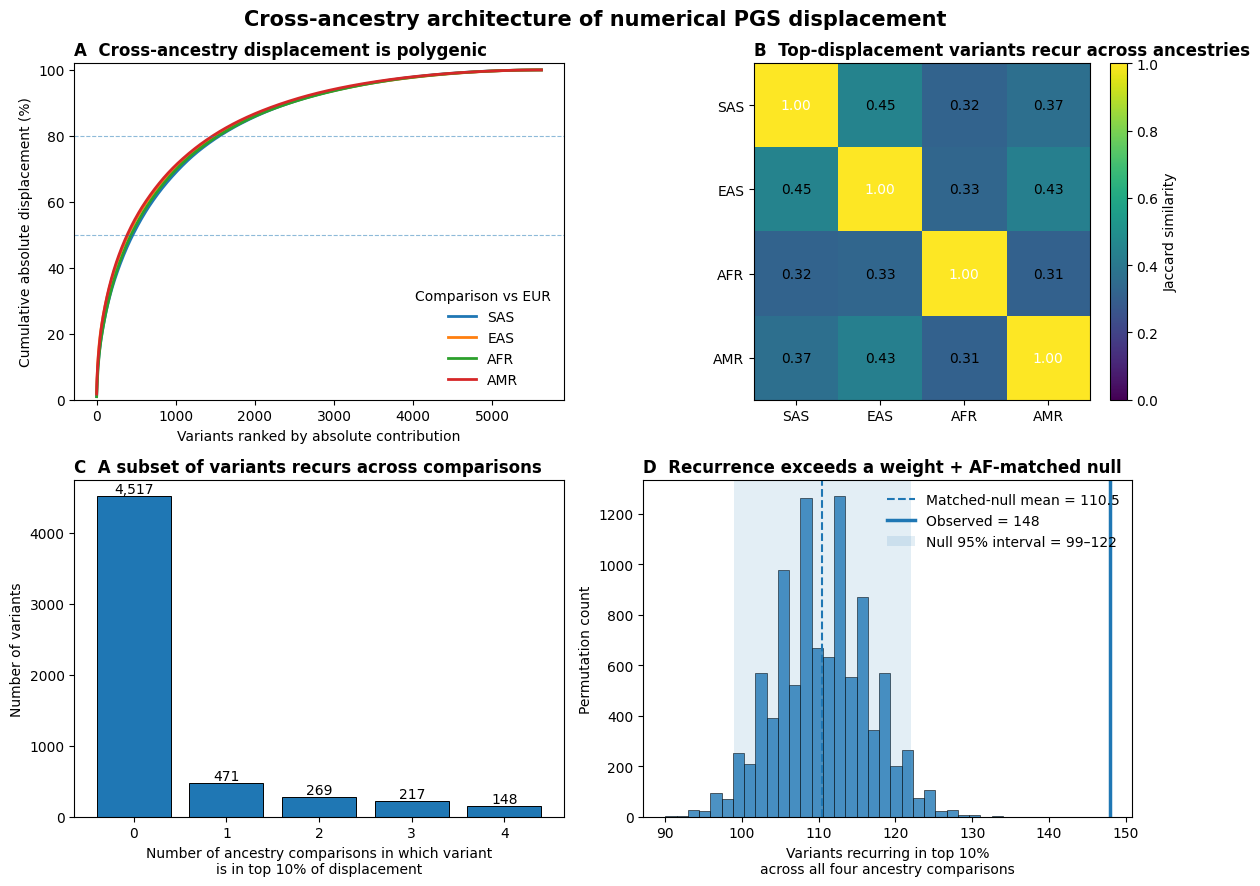

In [24]:
# Figure 2: numerical displacement architecture and recurrence

curve_data = {}

for ancestry in ancestries:
    values = (
        freq[f"abs_delta_{ancestry}"]
        .dropna()
        .sort_values(ascending=False)
        .to_numpy()
    )
    curve_data[ancestry] = np.cumsum(values) / values.sum()

jaccard = pd.DataFrame(
    np.eye(len(ancestries)),
    index=ancestries,
    columns=ancestries
)

for _, row in pairwise_overlap.iterrows():
    a, b = row["comparison"].split("-")
    jaccard.loc[a, b] = row["jaccard"]
    jaccard.loc[b, a] = row["jaccard"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axA, axB, axC, axD = axes.flatten()

# A: cumulative displacement
for ancestry in ancestries:
    y = curve_data[ancestry]
    axA.plot(np.arange(1, len(y) + 1), y * 100, linewidth=2, label=ancestry)

for threshold in [50, 80]:
    axA.axhline(threshold, linestyle="--", linewidth=0.8, alpha=0.5)

axA.set_xlabel("Variants ranked by absolute contribution")
axA.set_ylabel("Cumulative absolute displacement (%)")
axA.set_title("A  Cross-ancestry displacement is polygenic", loc="left", fontweight="bold")
axA.set_ylim(0, 102)
axA.legend(frameon=False, title="Comparison vs EUR")

# B: pairwise Jaccard similarity
matrix = jaccard.values
im = axB.imshow(matrix, vmin=0, vmax=1, aspect="equal")

axB.set_xticks(range(len(ancestries)), ancestries)
axB.set_yticks(range(len(ancestries)), ancestries)
axB.set_title("B  Top-displacement variants recur across ancestries", loc="left", fontweight="bold")

for i in range(len(ancestries)):
    for j in range(len(ancestries)):
        value = matrix[i, j]
        axB.text(
            j, i, f"{value:.2f}",
            ha="center", va="center",
            color="white" if value > 0.55 else "black"
        )

fig.colorbar(im, ax=axB, fraction=0.046, pad=0.04, label="Jaccard similarity")

# C: recurrence counts
x = np.arange(5)
bars = axC.bar(x, recurrence.values, edgecolor="black", linewidth=0.7)

axC.set_xticks(x)
axC.set_xlabel("Number of ancestry comparisons in which variant\nis in top 10% of displacement")
axC.set_ylabel("Number of variants")
axC.set_title("C  A subset of variants recurs across comparisons", loc="left", fontweight="bold")

for bar, count in zip(bars, recurrence.values):
    axC.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

# D: matched permutation null
axD.hist(null_counts, bins=30, edgecolor="black", linewidth=0.5, alpha=0.8)
axD.axvline(null_mean, linestyle="--", linewidth=1.5, label=f"Matched-null mean = {null_mean:.1f}")
axD.axvline(observed, linewidth=2.5, label=f"Observed = {observed}")
axD.axvspan(ci_low, ci_high, alpha=0.12, label=f"Null 95% interval = {ci_low:.0f}–{ci_high:.0f}")

axD.set_xlabel("Variants recurring in top 10%\nacross all four ancestry comparisons")
axD.set_ylabel("Permutation count")
axD.set_title("D  Recurrence exceeds a weight + AF-matched null", loc="left", fontweight="bold")
axD.legend(frameon=False)

fig.suptitle(
    "Cross-ancestry architecture of numerical PGS displacement",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

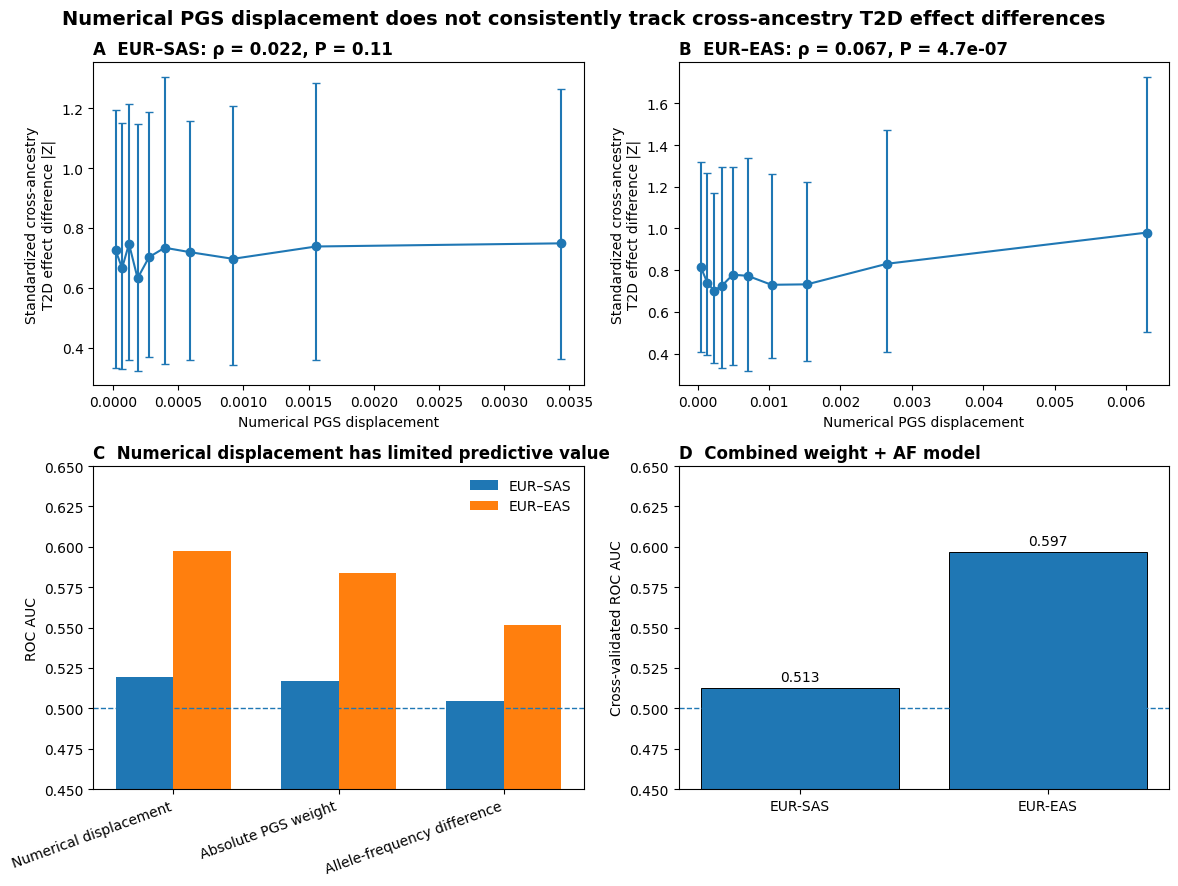

In [23]:
# Figure 3: numerical displacement vs cross-ancestry T2D effect differences

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axA, axB, axC, axD = axes.flatten()

for ax, ancestry, panel in [
    (axA, "SAS", "A"),
    (axB, "EAS", "B")
]:
    disp = comparisons[ancestry]["displacement"]
    effect_diff = comparisons[ancestry]["effect_difference"]

    d = effect[[disp, effect_diff]].dropna().copy()
    d["bin"] = pd.qcut(d[disp], 10, labels=False, duplicates="drop")

    summary = (
        d.groupby("bin")
        .agg(
            displacement=(disp, "median"),
            effect_median=(effect_diff, "median"),
            q25=(effect_diff, lambda x: x.quantile(0.25)),
            q75=(effect_diff, lambda x: x.quantile(0.75))
        )
        .reset_index()
    )

    rho, p = spearmanr(d[disp], d[effect_diff])

    ax.errorbar(
        summary["displacement"],
        summary["effect_median"],
        yerr=[
            summary["effect_median"] - summary["q25"],
            summary["q75"] - summary["effect_median"]
        ],
        fmt="o-",
        capsize=3
    )

    ax.set_xlabel("Numerical PGS displacement")
    ax.set_ylabel("Standardized cross-ancestry\nT2D effect difference |Z|")
    ax.set_title(
        f"{panel}  EUR–{ancestry}: ρ = {rho:.3f}, P = {p:.2g}",
        loc="left",
        fontweight="bold"
    )

# C: individual predictors
auc_table = prediction_results.pivot(
    index="predictor",
    columns="comparison",
    values="roc_auc"
)

predictor_order = [
    "numerical_displacement",
    "PGS_weight",
    "AF_difference"
]

labels = [
    "Numerical displacement",
    "Absolute PGS weight",
    "Allele-frequency difference"
]

x = np.arange(len(predictor_order))
width = 0.35

axC.bar(
    x - width / 2,
    auc_table.loc[predictor_order, "EUR-SAS"],
    width,
    label="EUR–SAS"
)

axC.bar(
    x + width / 2,
    auc_table.loc[predictor_order, "EUR-EAS"],
    width,
    label="EUR–EAS"
)

axC.axhline(0.5, linestyle="--", linewidth=1)
axC.set_xticks(x, labels, rotation=20, ha="right")
axC.set_ylabel("ROC AUC")
axC.set_ylim(0.45, 0.65)
axC.set_title(
    "C  Numerical displacement has limited predictive value",
    loc="left",
    fontweight="bold"
)
axC.legend(frameon=False)

# D: five-fold cross-validated combined model
cv_plot = cv_results.set_index("comparison")

comparisons_plot = ["EUR-SAS", "EUR-EAS"]
values = cv_plot.loc[comparisons_plot, "roc_auc"]

bars = axD.bar(comparisons_plot, values, edgecolor="black", linewidth=0.7)

axD.axhline(0.5, linestyle="--", linewidth=1)
axD.set_ylabel("Cross-validated ROC AUC")
axD.set_ylim(0.45, 0.65)
axD.set_title(
    "D  Combined weight + AF model",
    loc="left",
    fontweight="bold"
)

for bar, value in zip(bars, values):
    axD.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.004,
        f"{value:.3f}",
        ha="center"
    )

fig.suptitle(
    "Numerical PGS displacement does not consistently track "
    "cross-ancestry T2D effect differences",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 6. Exploratory local LD analysis

An outcome-blind random sample of variants was used to test whether ancestry differences in local linkage disequilibrium were associated with discordance between numerical PGS displacement and standardized cross-ancestry T2D effect differences.

In [5]:
# Exploratory local LD results

ld = pd.read_csv(
    f"{BASE}/LD_clean_random_targets_results.csv"
)

ld_rows = []

for ancestry in ["SAS", "EAS"]:
    discordance = f"discordance_{ancestry}"

    for metric, label in [
        (f"mean_abs_r2_difference_{ancestry}", "Mean |Δr²|"),
        (f"max_abs_r2_difference_{ancestry}", "Max |Δr²|")
    ]:
        d = ld[[discordance, metric]].dropna()

        rho, p = spearmanr(
            d[metric],
            d[discordance]
        )

        ld_rows.append({
            "comparison": f"EUR-{ancestry}",
            "metric": label,
            "n": len(d),
            "rho": rho,
            "p_value": p
        })

ld_results = pd.DataFrame(ld_rows)

print(ld_results)

  comparison      metric    n       rho   p_value
0    EUR-SAS  Mean |Δr²|  399  0.071930  0.151528
1    EUR-SAS   Max |Δr²|  399 -0.051667  0.303250
2    EUR-EAS  Mean |Δr²|  379  0.005631  0.912997
3    EUR-EAS   Max |Δr²|  379 -0.002317  0.964142


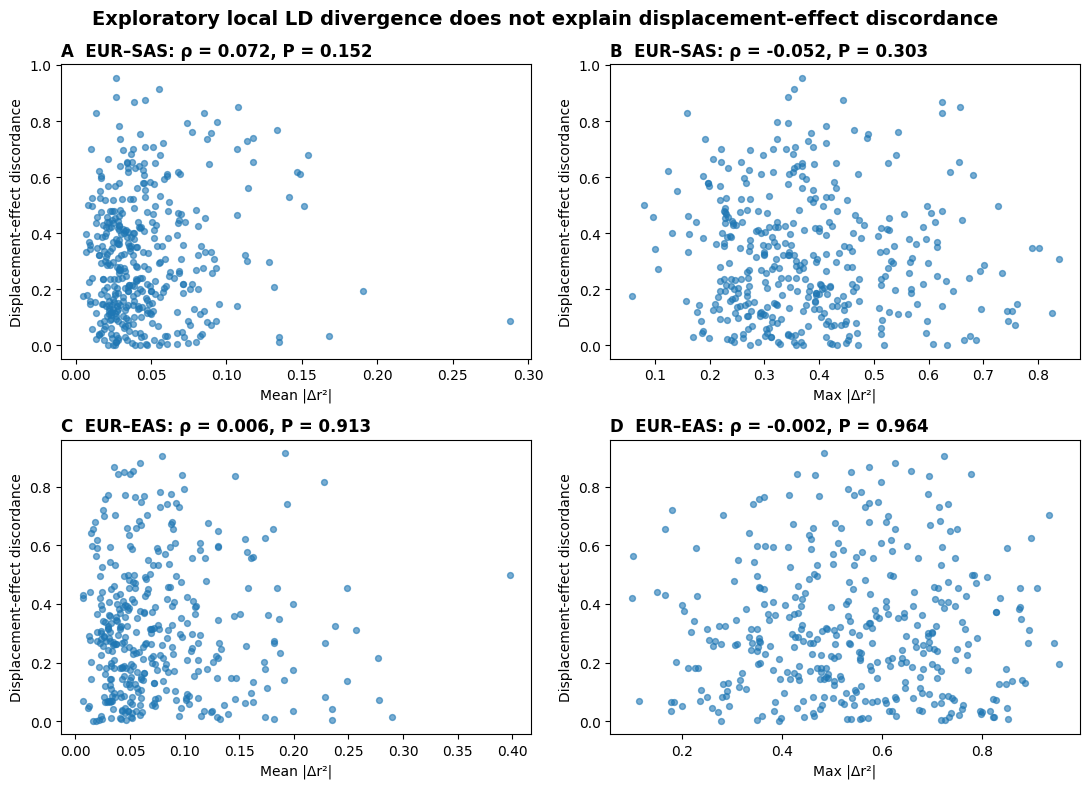

In [22]:
# Supplementary Figure S1: exploratory local LD analysis

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

panels = [
    ("SAS", "mean_abs_r2_difference_SAS", "Mean |Δr²|", "A"),
    ("SAS", "max_abs_r2_difference_SAS", "Max |Δr²|", "B"),
    ("EAS", "mean_abs_r2_difference_EAS", "Mean |Δr²|", "C"),
    ("EAS", "max_abs_r2_difference_EAS", "Max |Δr²|", "D")
]

for ax, (ancestry, metric, xlabel, panel) in zip(axes.flatten(), panels):
    discordance = f"discordance_{ancestry}"

    d = ld[[metric, discordance]].dropna()

    rho, p = spearmanr(
        d[metric],
        d[discordance]
    )

    ax.scatter(
        d[metric],
        d[discordance],
        s=18,
        alpha=0.6
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Displacement-effect discordance")
    ax.set_title(
        f"{panel}  EUR–{ancestry}: ρ = {rho:.3f}, P = {p:.3g}",
        loc="left",
        fontweight="bold"
    )

fig.suptitle(
    "Exploratory local LD divergence does not explain "
    "displacement-effect discordance",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 7. Reproducibility checks

The following cells summarize the principal numerical results reported in the manuscript and record the software environment used for the analyses.

In [21]:
# Final manuscript result checks

print("VARIANT UNIVERSE")
print("Total variants:", len(freq))

print("\nRECURRENCE")
print(recurrence)
print("Four-way recurrence:", observed)
print(f"Matched-null mean: {null_mean:.2f}")
print(f"Matched-null 95% interval: {ci_low:.0f}-{ci_high:.0f}")
print(f"Empirical P: {p_empirical:.6f}")

print("\nEFFECT-DIFFERENCE CORRELATIONS")
print(effect_correlations.to_string(index=False))

print("\nPREDICTION")
print(prediction_results.to_string(index=False))
print()
print(cv_results.to_string(index=False))

print("\nEXPLORATORY LD")
print(ld_results.to_string(index=False))

VARIANT UNIVERSE
Total variants: 5622

RECURRENCE
top10_count
0    4517
1     471
2     269
3     217
4     148
Name: count, dtype: int64
Four-way recurrence: 148
Matched-null mean: 110.48
Matched-null 95% interval: 99-122
Empirical P: 0.000100

EFFECT-DIFFERENCE CORRELATIONS
comparison    n      rho      p_value
   EUR-SAS 5620 0.021541 1.063760e-01
   EUR-EAS 5618 0.067163 4.688191e-07

PREDICTION
comparison              predictor  roc_auc  average_precision
   EUR-SAS numerical_displacement 0.519290           0.112711
   EUR-SAS             PGS_weight 0.516611           0.113187
   EUR-SAS          AF_difference 0.504310           0.104183
   EUR-EAS numerical_displacement 0.597158           0.167631
   EUR-EAS             PGS_weight 0.583785           0.165127
   EUR-EAS          AF_difference 0.551628           0.115993

comparison  roc_auc  average_precision
   EUR-SAS 0.512798           0.112246
   EUR-EAS 0.596871           0.164821

EXPLORATORY LD
comparison     metric   n    

In [13]:
# Software environment

import sys
import scipy
import sklearn
import matplotlib

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3
SciPy: 1.16.3
scikit-learn: 1.6.1
Matplotlib: 3.10.0
